In [426]:
#@title Import packages
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import h5py

In [632]:
animals_info ={
    'VG29':[['2025_10_10', '2']]
}
base1 = Path('/home/sunr@hhmi.org/nearline4_pachitariulab/data/PROC')
base2 = Path('/home/sunr@hhmi.org/dm11_pachitariulab/data/PROC')

In [529]:
for mname, sessions in animals_info.items():
    for datexp, blk in sessions:
        root = (base1 / mname / datexp / blk) if (base1 / mname / datexp / blk).exists() else (base2 / mname / datexp / blk)
        fpath = root / f"Timeline_{mname}_{datexp}_{blk}_raw.mat"
        fpath2 = root / f"Timeline_{mname}_{datexp}_{blk}.mat"
        if not fpath.exists():
            print(f"[skip] not found: {fpath}")
            continue
        try:
            data = loadmat(str(fpath2)) 
            data_raw = h5py.File(fpath, 'r')
            print(f"[ok] {fpath.name} → keys: {list(data.keys())}")
            print(f"     {fpath2.name} → keys: {list(data.keys())}")
            print(data['TL'].dtype) 
            print(data_raw['TL'].attrs)
        except Exception as e:
            # Optional: print the header to confirm file type
            with open(fpath, "rb") as fh:
                header = fh.read(128)
            print(f"[fail] {fpath}\n  {type(e).__name__}: {e}\n  header: {header[:64]!r} ...")


[ok] Timeline_VG29_2025_10_10_2_raw.mat → keys: ['__header__', '__version__', '__globals__', 'TL', '__function_workspace__']
     Timeline_VG29_2025_10_10_2.mat → keys: ['__header__', '__version__', '__globals__', 'TL', '__function_workspace__']
[('stim', 'O'), ('imaging', 'O'), ('save_flag', 'O'), ('stop_flag', 'O'), ('daq', 'O'), ('sess', 'O'), ('myMQTT', 'O'), ('beh', 'O')]
<Attributes of HDF5 object at 129885684822352>


In [530]:
def unwrap(v):
    while isinstance(v, np.ndarray) and v.dtype == object and v.size == 1:
        v = v.item()
    # turn (1,N) -> (N,), ['x'] -> 'x'
    if isinstance(v, np.ndarray):
        return np.squeeze(v)
    return v

def struct_to_dict(a):
    x = a

    while isinstance(x, np.ndarray) and x.dtype == object and x.size == 1:
        x = x.item()

    # x should often shape (1,1) or (1,)
    if isinstance(x, np.ndarray) and x.dtype.names:
        x = np.squeeze(x)
        # Case 1: a single record
        if x.shape == ():
            return {name: unwrap(x[name]) for name in x.dtype.names}
        # Case 2: multiple records
        out = {}
        for name in x.dtype.names:
            vals = []
            for idx in np.ndindex(x.shape):
                vals.append(unwrap(x[idx][name]))
            out[name] = vals
        return out

    if isinstance(x, np.void) and x.dtype.names:
        return {name: unwrap(x[name]) for name in x.dtype.names}


In [531]:
stim_lst = struct_to_dict(data['TL']['stim'])
print(stim_lst.keys())
sess_lst = struct_to_dict(data['TL']['sess'])
print(sess_lst.keys())
mname, datexp, blk = sess_lst['mname'], sess_lst['datexp'], sess_lst['blockexp']
beh_lst = struct_to_dict(data['TL']['beh'])
print(beh_lst.keys())

dict_keys(['cond_microscope', 'cond_run', 'fname', 'img', 'nimg', 'istims', 'pos_rew', 'iscreen', 'frame', 'data', 'colormask', 'window', 'destRect', 'dshift', 'time', 'distance', 'lickport', 'istim', 'gave_water', 'sound_time'])
dict_keys(['srate', 'mname', 'datexp', 'fdata', 'blockexp', 'readL', 'sread'])
dict_keys(['iface', 'face', 'eye_position', 'face_time', 'pup'])


In [532]:
def beh_from_fraction(fr, gray_cut=2/3, start_index=1):

    N = fr.size

    out = {}

    # Fraction within current trial [0,1)
    frac = np.full(N, np.nan)
    frac = np.mod(fr, 1.0)

    # Trial index (1-based, relative to first valid sample)
    ft_trInd = np.full(N, np.nan)
    base_int = np.floor(fr[0])
    ft_trInd = np.floor(fr) - base_int + start_index

    # Odd/even masks (False where NaN)
    odd_mask = np.zeros(N, dtype=bool)
    even_mask = np.zeros(N, dtype=bool)
    ti = ft_trInd.astype(int)
    odd_mask = (ti % 2 == 1)
    even_mask = (ti % 2 == 0)

    # Gray vs texture masks
    ft_GraySpc = np.zeros(N, dtype=bool)
    ft_CorrSpc = np.zeros(N, dtype=bool)
    ft_GraySpc = frac >= gray_cut
    ft_CorrSpc = frac < gray_cut

    out['ft_trInd'] = ft_trInd     
    out['ft_trInd_odd'] = odd_mask    
    out['ft_trInd_even'] = even_mask  
    out['ft_GraySpc'] = ft_GraySpc   
    out['ft_CorrSpc'] = ft_CorrSpc  
    return out

In [652]:
def beh_pos_istim(istim, trial_len=0.6, fps=None):

    N = istim.size

    # Fraction within trial, position in [0, 0.6)
    frac = np.full(N, np.nan)
    f = np.mod(istim, 1.0)
    #f = np.minimum(f, np.nextafter(1.0, 0.0))  # avoid 1, stays in [0,1)
    frac = f

    ft_Pos = np.full(N, np.nan)
    ft_Pos = trial_len * frac

    # Cum posn across trials 
    ft_PosCum = np.full(N, np.nan)
    base = np.floor(istim[0])               
    tr_rel = np.floor(istim) - base          
    ft_PosCum = trial_len * (tr_rel + frac)
    ft_PosCum -= ft_PosCum[0]


    ft_move = np.zeros(N, dtype=float)
    prev_mask = np.r_[False, np.ones(N-1, dtype=bool)]
    d = np.diff(ft_PosCum, prepend=np.nan)
    ft_move[prev_mask] = d[prev_mask]

    ft_isMoving = ft_move > 0

    # Running speed: distance/frame, or distance/sec if fps provided
    ft_RunSpeed = ft_move if fps is None else ft_move * float(fps)

    return {
    'ft_RunSpeed': ft_RunSpeed,
    'ft_Pos': ft_Pos,
    'ft_PosCum': ft_PosCum,
    'ft_move': ft_move,
    'ft_isMoving': ft_isMoving,
    }


In [634]:
from scipy import interpolate
def beh_lick_info(stim_lst, beh):
    lickport = stim_lst['lickport']
    licktime = stim_lst['time'][lickport == 2]
    assert np.unique(lickport[1:])[0] == 0 and np.unique(lickport[1:])[1] == 2, ValueError("Unexpected lickport values")
    lickfr = interpolate.interp1d(beh['ft'], np.arange(len(beh['ft'])), fill_value='extrapolate', kind='nearest')(licktime)
    print(f'lickfr num: {len(lickfr)}')
    '''
    lickport = lickport == 2  # boolean array, True when lick
    lick = nearest_from(stim_lst['time'], lickport, beh['ft'])
    print(f'lick shape: {lick.shape}, num: {np.sum(lick)}')

    beh['LickTrind'] = beh['ft_trInd'][lick]
    beh['LickTime'] = beh['ft'][lick]
    beh['LickPos'] = beh['ft_Pos'][lick]
    beh['Lick_wallName'] = beh['ft_WallID'][lick]
    beh['LickFr'] = np.where(lick)[0]
    '''
    beh['LickFr'] = lickfr
    beh['LickTime'] = beh['ft'][np.rint(lickfr).astype(int)]
    beh['LickPos'] = beh['ft_Pos'][np.rint(lickfr).astype(int)]
    beh['Lick_wallName'] = beh['ft_WallID'][np.rint(lickfr).astype(int)]
    beh['LickTrind'] = beh['ft_trInd'][np.rint(lickfr).astype(int)]

    plt.figure()
    #plt.plot(lickport[:10000], label='lickport', zorder=0)
    plt.scatter(licktime, 2*np.ones_like(licktime), marker='.', alpha=0.5, color = 'tab:blue')
    plt.scatter(beh['LickTime'], np.ones_like(beh['LickTime']), marker='.', alpha=0.5, color = 'tab:orange')
    plt.ylim([0.2, 2.2])
    plt.yticks([1, 2], ['fr_lick', 'lickport'])
    plt.show()

    return beh

In [626]:
def trial_frame_indices_from_imaging(beh, reward_fr):

    ft_trInd = beh['ft_trInd']
    ft_GraySpc = beh['ft_GraySpc']

    if np.all(np.isnan(ft_trInd)):
        ntrials = 0
    else:
        ntrials = int(np.nanmax(ft_trInd))
    beh['ntrials'] = ntrials

    RewardFr = np.full(ntrials, -1).astype(float)
    StartFr = np.full(ntrials, np.nan)
    GrayFr = np.full(ntrials, np.nan)
    EndFr = np.full(ntrials, np.nan)

    for tr in range(1, ntrials + 1):
        mask = (ft_trInd == tr)
        if not np.any(mask):
            continue  # trial not present on imaging frames

        idx_all = np.flatnonzero(mask)
        StartFr[tr-1] = idx_all[0]
        EndFr[tr-1] = idx_all[-1]

        idx_gray = np.flatnonzero(mask & ft_GraySpc)
        if idx_gray.size:
            GrayFr[tr-1] = idx_gray[0]

        if RewardFr[tr-1] != -1:
            continue
        for r in reward_fr:
            if r > idx_all[0] and r < idx_all[-1]: #and beh['ft_Pos'][np.rint(r).astype(int)] >= 0.05 and beh['ft_Pos'][np.rint(r).astype(int)] <= 0.4:
                RewardFr[tr-1] = r
                break
        if RewardFr[tr-1] == -1:
            RewardFr[tr-1] = np.nan


    beh['RewardFr'] = RewardFr
    beh['StartFr'] = StartFr
    beh['GrayFr'] = GrayFr
    beh['EndFr'] = EndFr
    return beh

In [621]:
from scipy.interpolate import interp1d
# special function to get stim times for this particular stimulus
def stim_times(dat, stim_lst, nmax = 1000):
    tdaq = dat['TL']['daq']['time']
    tdaq = np.array(tdaq).flatten().astype(float)
    idaq = 80 * (1+np.arange(len(tdaq))).astype(float)
    arr = np.asarray(dat['TL']['daq']['data'])
    if arr.ndim == 2:
        # shape (80, nPackets) -> column-major flatten
        if arr.shape[0] == 80:
            ddaq = arr.reshape(-1, order='F')
        # shape (nPackets, 80) -> row-major flatten
        elif arr.shape[1] == 80:
            ddaq = arr.reshape(-1, order='C')
        else:
            ddaq = arr.T.reshape(-1)  # fallback
    else:
        ddaq = arr.T.reshape(-1) 

    ix = (ddaq[1:] <= 2.5) * (ddaq[:-1] > 2.5)
    imic = ix.nonzero()[0].astype(float)

    tmic = np.interp(imic, idaq, tdaq)


    istim = stim_lst['istim']
    tstim = stim_lst['time']
    istim = istim[:len(tstim)]

    
    f = interp1d(tstim, istim, fill_value = 'extrapolate', kind='nearest')
    istim = f(tmic)

    plt.figure()
    plt.plot(istim)
    plt.show()

    return istim, tmic

## Align Time! (If Imaging == 1)

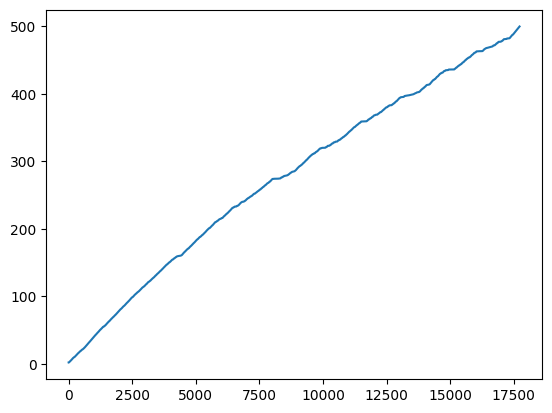

(17725,)
ntrials: 498, total frames: 17724
wall names: (498,)
reward trial num: 200
RewardFr num: 200; RewardFr: (498,)
lickfr num: 5255


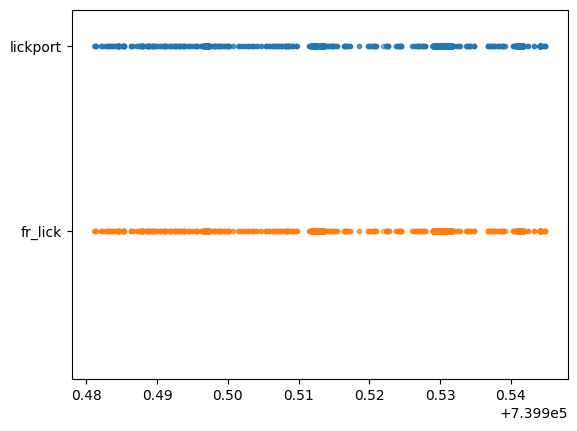

In [705]:
max_trials = 500
istim, ft = stim_times(data_raw, stim_lst, nmax=1000)
print(istim.shape)

#beh = beh_from_fraction(stim_lst['istim'])
beh = beh_from_fraction(istim[(istim>=2) & (istim<max_trials)])
beh['istim'] = istim

beh['ntrials'] = beh['ft_trInd'].max().astype(int)
ntrials = beh['ntrials']
print(f'ntrials: {ntrials}, total frames: {len(beh["ft_trInd"])}')

#tot_tr = stim_lst['istims'].shape[0]
tot_tr = ntrials+1

# stim_lst['istims'] 1: kiwi; 4. masked kiwi; 14. stone; 17. masked stone; reward only for kiwi trials
# encode the stim id as 0,1,2,3: stone (0), masked stone (1), kiwi (2), masked kiwi (3)
beh['stim_id'] = np.array([0,1,2,3])
beh['UniqWalls'] = np.array(['stone', 'mstone', 'kiwi', 'mkiwi'])
beh['WallName'] = np.array(['']*tot_tr, dtype=object)
beh['WallName'][stim_lst['istims'][:tot_tr]==1] = 'kiwi'
beh['WallName'][stim_lst['istims'][:tot_tr]==4] = 'mkiwi'
beh['WallName'][stim_lst['istims'][:tot_tr]==14] = 'stone'
beh['WallName'][stim_lst['istims'][:tot_tr]==17] = 'mstone'
beh['WallName'] = beh['WallName'][tot_tr-ntrials:]  # only keep the last ntrials
print(f'wall names: {beh["WallName"].shape}')

beh['RewPos'] = (stim_lst['pos_rew']*0.6)[:tot_tr]
beh['RewPos'][stim_lst['istims'][:tot_tr]!=1] = np.nan  # no-reward trials
beh['RewPos'] = beh['RewPos'][tot_tr-ntrials:]  # only keep the last ntrials
print(f'reward trial num: {np.sum(~np.isnan(beh["RewPos"]))}')

beh['SoundPos'] = (stim_lst['pos_rew']*0.6)[:tot_tr][tot_tr-ntrials:]

#beh['ft'] = stim_lst['time']
beh['ft'] = ft[(istim>=2) & (istim<max_trials)]

# frac of the stim to present at each frame
#beh['istim'] = stim_lst['istim']

# Frame is True if gave water, bool value
#beh['ft_reward'] = np.empty(len(stim_lst['gave_water']), dtype=bool)
#beh['ft_reward'] = stim_lst['gave_water'] == 1
gave_water = stim_lst['time'][stim_lst['gave_water']==1]
reward_fr = interpolate.interp1d(beh['ft'], np.arange(len(beh['ft'])), fill_value='extrapolate', kind='nearest')(gave_water)

beh_pos = beh_pos_istim(istim[(istim>=2) & (istim<max_trials)], trial_len=0.6, fps=None)

beh['ft_RunSpeed'], beh['ft_Pos'], beh['ft_PosCum'], beh['ft_move'], beh['ft_isMoving'] = beh_pos['ft_RunSpeed'], beh_pos['ft_Pos'], beh_pos['ft_PosCum'], beh_pos['ft_move'], beh_pos['ft_isMoving']

beh['ft_WallID'] = np.array(['']*len(beh['ft']), dtype=object)

beh['SoundFr'] = interpolate.interp1d(beh['ft_Pos']+beh['ft_trInd']+1, np.arange(len(beh['ft_Pos']+beh['ft_trInd']+1)), fill_value='extrapolate', kind='nearest')(beh['SoundPos']+range(2, 500))

for i in range(1, tot_tr):
    beh['ft_WallID'][np.floor(istim[(istim>=2) & (istim<max_trials)])==i+1] = beh['WallName'][i - 1]

beh = trial_frame_indices_from_imaging(beh, reward_fr)
print(f'RewardFr num: {np.sum(~np.isnan(beh["RewardFr"]))}; RewardFr: {beh["RewardFr"].shape}')

beh = beh_lick_info(stim_lst, beh)

In [661]:
bad = np.flatnonzero((~np.isnan(beh['RewardFr'])) & (beh['WallName'] != 'kiwi'))
print(bad, bad+1, beh['WallName'][bad], beh['RewardFr'][bad])


[] [] [] []


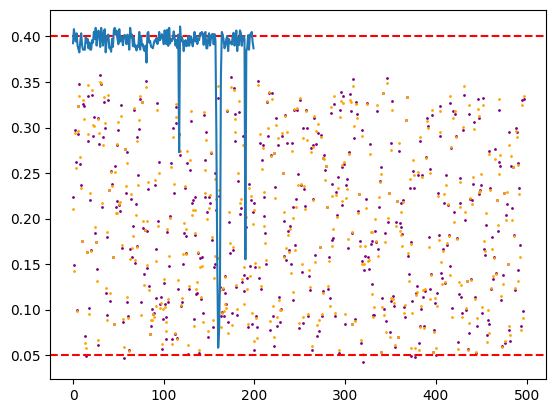

In [712]:
valid = beh['RewardFr'][~np.isnan(beh['RewardFr'])]
plt.figure()
plt.axhline(y=0.05, color='r', linestyle='--')
plt.axhline(y=0.4, color='r', linestyle='--')
plt.plot(beh['ft_Pos'][np.rint(valid).astype(int)])
#plt.scatter(beh['LickFr'], beh['ft_Pos'][np.rint(beh['LickFr']).astype(int)], color='orange', s=1)
plt.scatter(np.arange(len(beh['SoundPos'])), beh['ft_Pos'][np.rint(beh['SoundFr']).astype(int)], color='purple', s=1)
plt.scatter(np.arange(len(beh['SoundPos'])), beh['SoundPos'], color='orange', s=1)
plt.show()

In [592]:
beh.keys()

dict_keys(['ft_trInd', 'ft_trInd_odd', 'ft_trInd_even', 'ft_GraySpc', 'ft_CorrSpc', 'istim', 'ntrials', 'stim_id', 'UniqWalls', 'WallName', 'RewPos', 'SoundPos', 'ft', 'ft_RunSpeed', 'ft_Pos', 'ft_PosCum', 'ft_move', 'ft_isMoving', 'ft_WallID', 'RewardFr', 'StartFr', 'GrayFr', 'EndFr', 'LickFr', 'LickTime', 'LickPos', 'Lick_wallName'])

In [707]:
root = '/media/sunr/C40AA1B70AA1A740/data/InfoInteg/data_newDeconv/beh'
beh_animals = {}
beh_animals[f'{mname}_{datexp}_{blk}'] = beh
np.save(os.path.join(root, f'Beh_sup_train1_before_learning.npy'), beh_animals)